# Fine-Tuning a Real Model, Step by Step — Company Text-to-SQL with LoRA


---
## Chapter 0 — Setup

**WHAT:** install libraries and pick the device.

| Library | Its job |
|---|---|
| `transformers` | model + tokenizer + the `Trainer` |
| `datasets` | stores our generated training rows in Hugging Face Dataset format |
| `peft` | turns the model into a LoRA model in one call |
| `accelerate` | handles GPU/CPU placement |



In [1]:
# ── Install (run once, then Runtime > Restart session) ─────────────────────
%pip install -q -U "transformers>=4.44" "datasets>=2.19" "accelerate>=0.30" matplotlib pandas
%pip install -q "peft==0.11.1"   # Colab: newer peft needs torchao>0.16 which Colab lacks
#
# (bitsandbytes is only needed for the QLoRA chapter on an NVIDIA GPU.)
print("If get_peft_model raises a torchao ImportError, or the dataset fails to load,")
print("run the two %pip lines above, then Runtime > Restart session, then re-run.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 whic

In [2]:
# ── Imports & device ───────────────────────────────────────────────────────
import warnings, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Pick the best available device. In Colab this should usually become "cuda".
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# Match the model dtype with the GPU. This avoids fp16/bf16 GradScaler errors on Colab.
USE_BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
USE_FP16 = DEVICE == "cuda" and not USE_BF16
MODEL_DTYPE = torch.bfloat16 if USE_BF16 else (torch.float16 if USE_FP16 else torch.float32)

# Fixed seeds make the demo more reproducible across reruns.
torch.manual_seed(42); np.random.seed(42)
print("PyTorch:", torch.__version__, "| Device:", DEVICE)
print("Train dtype:", MODEL_DTYPE)
if DEVICE == "cpu":
    print("NOTE: no GPU detected — training will work but be slow. Use Colab (T4) if you can.")

PyTorch: 2.11.0+cu128 | Device: cuda
Train dtype: torch.bfloat16


---
## Chapter 1 — The Real-Life Scenario

**Scenario:**
> "A training company has an internal training-operations database. Managers ask questions like
> *'show dormant paid learners in GenAI'* or *'count hot prospects for MLOps'*. A generic model may
> know SQL syntax, but it does **not** know our private meanings:
>
> - `active learner` = `status_code = 'A' AND is_deleted = 0`
> - `paid learner` = `plan_code IN ('PRO', 'TEAM')`
> - `dormant` = `last_login_days >= 14`
> - `payment risk` = `unpaid_days > 0`
> - `hot prospect` = `lead_score >= 80 AND demo_attended = 1 AND stage_code IN ('TRIAL', 'DEMO')`
>
> We will fine-tune the model so it learns this contract from examples."

```
   Qwen2.5-0.5B (base)   +   LoRA on company examples   =   SQL assistant with company rules
   knows generic SQL          private vocabulary              exact internal query style
```

**WHY a base model can still fail here:** it may output valid-looking SQL, but it will miss the
private mappings. That makes this a stronger fine-tuning example than asking for simple public SQL.


---
## Chapter 2 — Load the Small Real Model

**WHAT:** download `Qwen2.5-0.5B` (~0.5 billion params) and its tokenizer.

**WHY Qwen2.5-0.5B?** Small enough to train in minutes on a free GPU, but modern enough that it
already knows SQL syntax. That is useful for this lesson: we can show that fine-tuning is not about
memorizing `SELECT`; it is about learning the private business rules around the SQL.


In [ ]:
# ── Load base model + tokenizer ────────────────────────────────────────────
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B"     # try "Qwen/Qwen2.5-1.5B" for even better SQL

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Decoder-only LLMs often have no pad token; using EOS as padding is standard for causal LM demos.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load the base model before LoRA. At this point all original weights are still trainable in theory.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {n_params:,}  (~{n_params/1e6:.0f} M)")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model: Qwen/Qwen2.5-0.5B
Total parameters: 494,032,768  (~494 M)


**WHAT:** one helper, `ask()`, that we call **before and after** training on the *same*
questions so the comparison is fair.

**HOW it works:** we give only the database schema and the user question. We do **not** put the
business glossary in the prompt. The only way the model can learn the glossary is from fine-tuning.


In [4]:
# ── Generation helper (used for BEFORE and AFTER) ──────────────────────────
def build_prompt(schema, question):
    # Keep this template identical for training and inference; SFT learns this exact pattern.
    return (f"### Database schema:\n{schema}\n\n"
            f"### Question:\n{question}\n\n"
            f"### SQL query:\n")

def ask(model, schema, question, max_new_tokens=80):
    prompt = build_prompt(schema, question)
    # Move tokenized input to the same device as the model to avoid CPU/GPU mismatch errors.
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )
    # Slice away the prompt tokens so we print only what the model newly generated.
    generated = out[0][inputs["input_ids"].shape[-1]:]
    text = tokenizer.decode(generated, skip_special_tokens=True)
    # Stop if the model starts another section such as ### Question or ### SQL query.
    return text.split("###")[0].strip()

def normalize_sql(sql):
    # A light normalization makes before/after comparison less sensitive to spacing and semicolons.
    return " ".join(sql.replace(";", " ;").split()).lower()

COMPANY_SCHEMA = """CREATE TABLE training_students (
  student_id INT,
  full_name TEXT,
  cohort TEXT,
  plan_code TEXT,
  status_code TEXT,
  risk_band TEXT,
  unpaid_days INT,
  last_login_days INT,
  assignments_pending INT,
  certificate_ready INT,
  is_deleted INT
);
CREATE TABLE training_leads (
  lead_id INT,
  full_name TEXT,
  course TEXT,
  stage_code TEXT,
  lead_score INT,
  demo_attended INT,
  last_contact_days INT,
  is_deleted INT
);"""

# Test cases use business words the base model cannot infer from the schema alone.
TESTS = [
    (
        COMPANY_SCHEMA,
        "List active paid learners in the GenAI cohort.",
        "SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;",
    ),
    (
        COMPANY_SCHEMA,
        "How many dormant learners have payment risk in Data Science?",
        "SELECT COUNT(*) FROM training_students WHERE cohort = 'Data Science' AND last_login_days >= 14 AND unpaid_days > 0 AND is_deleted = 0;",
    ),
    (
        COMPANY_SCHEMA,
        "Show hot prospects for the MLOps course.",
        "SELECT full_name FROM training_leads WHERE course = 'MLOps' AND lead_score >= 80 AND demo_attended = 1 AND stage_code IN ('TRIAL', 'DEMO') AND is_deleted = 0;",
    ),
]
print("Helper ready.")


Helper ready.


---
## Chapter 3 — BEFORE: The Raw Model Knows SQL, But Not Our Company Rules

**WHAT:** run the base model on the three business questions.

**WHY first:** this is the "before" photo. The model may produce valid-looking SQL, but it usually
misses the hidden contract: status codes, plan codes, soft-delete filters, lead-stage rules, and
thresholds. That is exactly what to look for in the baseline output.


In [5]:
# ── Baseline: BEFORE any fine-tuning ───────────────────────────────────────
print("="*72)
print("BEFORE FINE-TUNING  (raw Qwen2.5-0.5B)")
print("="*72)
for schema, q, target in TESTS:
    pred = ask(model, schema, q)
    print(f"\nQ: {q}")
    print("TARGET:", target)
    print("MODEL :", pred)
    # Before fine-tuning, these should mostly be False because the base model does not know the private rules.
    print("MATCH :", normalize_sql(pred) == normalize_sql(target))


BEFORE FINE-TUNING  (raw Qwen2.5-0.5B)

Q: List active paid learners in the GenAI cohort.
TARGET: SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;
MODEL : ```sql
SELECT
  student_id,
  full_name,
  cohort,
  plan_code,
  status_code,
  risk_band,
  unpaid_days,
  last_login_days,
  assignments_pending,
  certificate_ready,
  is_deleted
FROM
  training_students
WHERE
  status_code = 'Active' AND
  risk_band = 'Low' AND
  unpaid_days >
MATCH : False

Q: How many dormant learners have payment risk in Data Science?
TARGET: SELECT COUNT(*) FROM training_students WHERE cohort = 'Data Science' AND last_login_days >= 14 AND unpaid_days > 0 AND is_deleted = 0;
MODEL : ```sql
SELECT COUNT(*) FROM training_students WHERE status_code = 'D' AND is_deleted = 0;
```
MATCH : False

Q: Show hot prospects for the MLOps course.
TARGET: SELECT full_name FROM training_leads WHERE course = 'MLOps' AND lead_score >= 80 A

---
## Chapter 4 — Build a Controlled Company SQL Dataset

**WHAT:** create realistic training examples for the training-operations schema.

**WHY not the public Text-to-SQL dataset here?** Simple SQL is now too easy for modern small models.
For understanding fine-tuning, we want a controlled behavior the base model cannot already know:
company vocabulary, encoded columns, thresholds, and a strict SQL house style.

The examples are synthetic, but the pattern is real: many teams fine-tune on internal query logs,
analytics conventions, CRM stages, support labels, compliance tags, or product-specific codes.


In [6]:
# ── Generate company Text-to-SQL examples ─────────────────────────────────
from datasets import Dataset
import random

rng = random.Random(42)
cohorts = ["GenAI", "Data Science", "MLOps", "Python", "NLP"]
courses = ["GenAI", "Data Science", "MLOps", "Python", "NLP"]
rows = []

def add(question, answer):
    # Each row is one supervised fine-tuning example: input question + expected SQL answer.
    rows.append({"context": COMPANY_SCHEMA, "question": question, "answer": answer})

def student_sql(select_expr, where):
    # Enforce the house rule in every student query: ignore soft-deleted rows.
    return f"SELECT {select_expr} FROM training_students WHERE {where} AND is_deleted = 0;"

def lead_sql(select_expr, where):
    # Same house rule for leads. The model learns this repeated pattern from examples.
    return f"SELECT {select_expr} FROM training_leads WHERE {where} AND is_deleted = 0;"

for _ in range(240):
    # Random course/cohort names create variety while keeping the SQL rules consistent.
    cohort = rng.choice(cohorts)
    course = rng.choice(courses)

    add(
        rng.choice([
            f"List active paid learners in the {cohort} cohort.",
            f"Who are the paid active students for {cohort}?",
            f"Show current paid learners from {cohort}.",
        ]),
        student_sql("full_name", f"cohort = '{cohort}' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM')"),
    )

    add(
        rng.choice([
            f"How many dormant learners have payment risk in {cohort}?",
            f"Count inactive students with unpaid dues for {cohort}.",
            f"Give me the number of payment-risk dormant learners in {cohort}.",
        ]),
        student_sql("COUNT(*)", f"cohort = '{cohort}' AND last_login_days >= 14 AND unpaid_days > 0"),
    )

    add(
        rng.choice([
            f"Which {cohort} learners need mentor attention?",
            f"List students requiring mentor follow-up in {cohort}.",
            f"Show at-risk learners for mentor review in {cohort}.",
        ]),
        student_sql("full_name", f"cohort = '{cohort}' AND (risk_band IN ('RED', 'AMBER') OR assignments_pending >= 3 OR last_login_days >= 7)"),
    )

    add(
        rng.choice([
            f"List certificate-ready learners in {cohort}.",
            f"Who can receive certificates for {cohort}?",
            f"Show active students ready for certification in {cohort}.",
        ]),
        student_sql("full_name", f"cohort = '{cohort}' AND certificate_ready = 1 AND status_code = 'A'"),
    )

    add(
        rng.choice([
            f"Show hot prospects for the {course} course.",
            f"List high-intent leads for {course}.",
            f"Which {course} prospects are sales-ready?",
        ]),
        lead_sql("full_name", f"course = '{course}' AND lead_score >= 80 AND demo_attended = 1 AND stage_code IN ('TRIAL', 'DEMO')"),
    )

    add(
        rng.choice([
            f"How many cold leads are there for {course}?",
            f"Count stale prospects in {course}.",
            f"Give the cold pipeline count for {course}.",
        ]),
        lead_sql("COUNT(*)", f"course = '{course}' AND (last_contact_days >= 21 OR lead_score < 40)"),
    )

    add(
        rng.choice([
            f"Show fresh trial leads for {course}.",
            f"List recently contacted trial prospects in {course}.",
            f"Which {course} trial leads are still fresh?",
        ]),
        lead_sql("full_name", f"course = '{course}' AND stage_code = 'TRIAL' AND last_contact_days <= 3"),
    )

full = Dataset.from_list(rows)
data = full.shuffle(seed=42)
print("Total generated rows:", len(full), "| using:", len(data))

print("\n--- One raw example ---")
ex = data[0]
print("context (schema):", ex["context"])
print("question       :", ex["question"])
print("answer (SQL)    :", ex["answer"])


Total generated rows: 1680 | using: 1680

--- One raw example ---
context (schema): CREATE TABLE training_students (
  student_id INT,
  full_name TEXT,
  cohort TEXT,
  plan_code TEXT,
  status_code TEXT,
  risk_band TEXT,
  unpaid_days INT,
  last_login_days INT,
  assignments_pending INT,
  certificate_ready INT,
  is_deleted INT
);
CREATE TABLE training_leads (
  lead_id INT,
  full_name TEXT,
  course TEXT,
  stage_code TEXT,
  lead_score INT,
  demo_attended INT,
  last_contact_days INT,
  is_deleted INT
);
question       : How many cold leads are there for Data Science?
answer (SQL)    : SELECT COUNT(*) FROM training_leads WHERE course = 'Data Science' AND (last_contact_days >= 21 OR lead_score < 40) AND is_deleted = 0;


**WHAT:** turn each row into ONE training string with the *same* template `ask()` uses.

**WHY the shared template (the core of SFT):** the model learns that after `### SQL query:` it
must produce the company-approved SQL. We append the end-of-text token so it learns **where to
stop**.


In [7]:
# ── Format every row into our template ─────────────────────────────────────
def to_text(row):
    # The answer is placed immediately after the prompt, so the model learns what to generate next.
    return {"text": build_prompt(row["context"], row["question"])
                    + row["answer"] + tokenizer.eos_token}

# remove_columns keeps only the final training text, which is all the Trainer needs.
dataset = data.map(to_text, remove_columns=data.column_names)
print("--- One FORMATTED training example (exactly what the model sees) ---\n")
print(dataset[0]["text"])

--- One FORMATTED training example (exactly what the model sees) ---

### Database schema:
CREATE TABLE training_students (
  student_id INT,
  full_name TEXT,
  cohort TEXT,
  plan_code TEXT,
  status_code TEXT,
  risk_band TEXT,
  unpaid_days INT,
  last_login_days INT,
  assignments_pending INT,
  certificate_ready INT,
  is_deleted INT
);
CREATE TABLE training_leads (
  lead_id INT,
  full_name TEXT,
  course TEXT,
  stage_code TEXT,
  lead_score INT,
  demo_attended INT,
  last_contact_days INT,
  is_deleted INT
);

### Question:
How many cold leads are there for Data Science?

### SQL query:
SELECT COUNT(*) FROM training_leads WHERE course = 'Data Science' AND (last_contact_days >= 21 OR lead_score < 40) AND is_deleted = 0;<|endoftext|>


**WHAT:** tokenize (text → numbers).

**WHY no `labels` and no `set_format('torch')`:** the data collator in Chapter 7 builds the
labels automatically (copy `input_ids`, mask padding to `-100`). We skip `set_format('torch')`
because it triggers a torchvision bug on Colab; the collator returns tensors anyway.

In [8]:
# ── Tokenize ───────────────────────────────────────────────────────────────
MAX_LEN = 256     # the schema plus answer fits comfortably in this window

def tokenize(batch):
    # Padding to a fixed length makes batches simple; truncation protects us from very long examples.
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN, padding="max_length")

# batched=True tokenizes many examples at once, which is much faster than row-by-row tokenization.
tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])
print("Tokenized", len(tokenized), "examples, each", MAX_LEN, "tokens.")


Tokenized 1680 examples, each 256 tokens.


---
## Chapter 5 — Why Not Train All the Weights? (the case for LoRA)

**WHY:** full fine-tuning stores weights + gradients + optimizer state for **every** parameter.
Even for 0.5B that's several GB; for a 7B model it's >100 GB. **LoRA** freezes the whole model
and trains a tiny low-rank add-on, cutting trainable parameters ~99.5%.

In [9]:
# ── The memory intuition (numbers, not a real allocation) ──────────────────
p = n_params
print(f"Full fine-tuning {p/1e6:.0f}M params (FP32, Adam):")
print(f"  weights   : {p*4/1e9:5.2f} GB")
print(f"  gradients : {p*4/1e9:5.2f} GB")
print(f"  optimizer : {p*8/1e9:5.2f} GB  (Adam: 2 extra values/weight)")
print(f"  TOTAL     : {p*16/1e9:5.2f} GB")
print("\nLoRA trains <1% of weights -> gradient + optimizer memory shrinks ~200x.")

Full fine-tuning 494M params (FP32, Adam):
  weights   :  1.98 GB
  gradients :  1.98 GB
  optimizer :  3.95 GB  (Adam: 2 extra values/weight)
  TOTAL     :  7.90 GB

LoRA trains <1% of weights -> gradient + optimizer memory shrinks ~200x.


---
## Chapter 6 — Apply LoRA (the whole trick is one function)

**WHY it works:** the *change* to a weight matrix during fine-tuning (`ΔW`) is almost always
**low-rank** — it can be written as two skinny matrices `B·A`. So we learn tiny `A` and `B`
(rank `r`) instead of the full matrix. `B` starts at zero, so training begins as an exact copy
of the base model and adapts gently.

**The knobs:**

| Setting | Meaning | Value |
|---|---|---|
| `r` | adapter capacity (↑ = more expressive) | 16 |
| `lora_alpha` | scaling; strength = `alpha/r` | 32 |
| `target_modules` | which layers get LoRA (Qwen's attention + MLP) | 7 projections |
| `lora_dropout` | regularization | 0.05 |
| `task_type` | causal language model | `CAUSAL_LM` |

**WHY target the MLP too (not just attention)?** For learning a *new skill* like SQL, adding
the feed-forward layers (`gate/up/down_proj`) noticeably improves quality. This is a key reason
this demo works where an attention-only adapter on a weaker model did not.

In [10]:
# ── The LoRA workflow ──────────────────────────────────────────────────────
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,                         # rank: adapter capacity; higher = more expressive but larger
    lora_alpha=32,                # scaling strength; effective scale is alpha / r
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",   # attention
                    "gate_proj", "up_proj", "down_proj"],      # MLP (helps a lot)
    lora_dropout=0.05,            # small regularization so adapters do not memorize too sharply
    bias="none",                  # train only LoRA matrices, not bias terms
    task_type="CAUSAL_LM",
)

# get_peft_model freezes the base model and inserts small trainable LoRA matrices.
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


**Check the number:** trainable params should be well under **1%** of the total.
This is the key LoRA idea: most weights stay frozen, and only a tiny adapter is trained.

---
## Chapter 7 — Train

**WHY the same `Trainer` as full fine-tuning:** PEFT is transparent — only the model changed
(frozen base + tiny adapters). The training loop is identical.

- `learning_rate=2e-4` — LoRA likes a higher LR than full fine-tuning (~2e-5).
- `num_train_epochs=3` — enough passes to learn SQL without overfitting 4k rows.
- lower `per_device_train_batch_size` if you hit out-of-memory.

*(On a Colab T4 this is roughly 3–6 minutes.)*

In [11]:
# ── Train ──────────────────────────────────────────────────────────────────
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

args = TrainingArguments(
    output_dir="./company-sql-lora-out",  # temporary training artifacts/checkpoints
    num_train_epochs=3,                   # repeat the small dataset enough times to learn the rules
    per_device_train_batch_size=8,         # lower this if Colab runs out of GPU memory
    gradient_accumulation_steps=2,         # effective batch = 8 * 2 = 16
    learning_rate=2e-4,                    # LoRA usually uses a higher LR than full fine-tuning
    logging_steps=20,                      # show loss every 20 optimizer steps
    fp16=USE_FP16,                       # use fp16 only on GPUs that do not support bf16
    bf16=USE_BF16,                       # avoids GradScaler bf16/fp16 mismatch on newer Colab GPUs
    save_strategy="no",                   # keep the demo folder small; we save adapter manually later
    report_to="none",                     # disable external logging services such as W&B
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized,
    # For causal LM, labels are the same tokens shifted internally; padding is ignored in the loss.
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

# This updates only the LoRA adapter weights, not the frozen base-model weights.
result = trainer.train()
print("\nDone. Final training loss:", round(result.training_loss, 4))


Step,Training Loss
20,0.564540
40,0.047052
60,0.034277
80,0.032077
100,0.030880
120,0.029871
140,0.030102
160,0.029400
180,0.029664
200,0.029837



Done. Final training loss: 0.0649


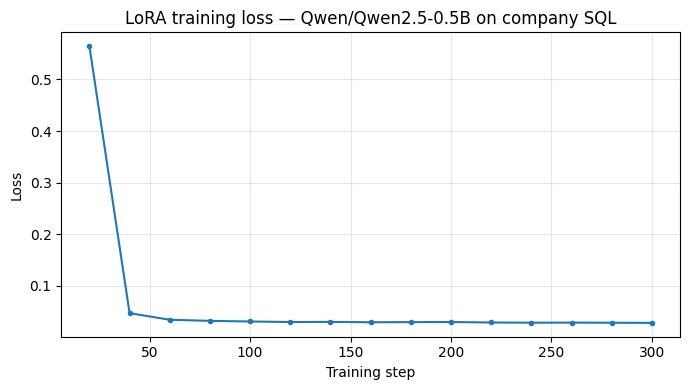

In [12]:
# ── Plot the training loss ─────────────────────────────────────────────────
hist = [h for h in trainer.state.log_history if "loss" in h]
plt.figure(figsize=(7,4))
plt.plot([h["step"] for h in hist], [h["loss"] for h in hist], marker="o", ms=3)
plt.xlabel("Training step"); plt.ylabel("Loss")
plt.title(f"LoRA training loss — {MODEL_NAME} on company SQL")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


---
## Chapter 8 — AFTER: The Same Model Learns the Company Contract

**WHAT:** run the **exact same three questions** through the fine-tuned model.

**WHY this is the payoff:** compare with Chapter 3. The model is no longer just producing generic
SQL. It should now use the internal codes, thresholds, and `is_deleted = 0` filter that were never
written in the prompt. This is the main evidence that fine-tuning changed the model behavior.


In [13]:
# ── The model AFTER fine-tuning ────────────────────────────────────────────
print("="*72)
print("AFTER FINE-TUNING  (Qwen2.5-0.5B + LoRA)")
print("="*72)
for schema, q, target in TESTS:
    pred = ask(model, schema, q)
    print(f"\nQ: {q}")
    print("TARGET:", target)
    print("MODEL :", pred)
    # After fine-tuning, these should become True if the adapter learned the private SQL rules.
    print("MATCH :", normalize_sql(pred) == normalize_sql(target))


AFTER FINE-TUNING  (Qwen2.5-0.5B + LoRA)

Q: List active paid learners in the GenAI cohort.
TARGET: SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;
MODEL : SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;
MATCH : True

Q: How many dormant learners have payment risk in Data Science?
TARGET: SELECT COUNT(*) FROM training_students WHERE cohort = 'Data Science' AND last_login_days >= 14 AND unpaid_days > 0 AND is_deleted = 0;
MODEL : SELECT COUNT(*) FROM training_students WHERE cohort = 'Data Science' AND last_login_days >= 14 AND unpaid_days > 0 AND is_deleted = 0;
MATCH : True

Q: Show hot prospects for the MLOps course.
TARGET: SELECT full_name FROM training_leads WHERE course = 'MLOps' AND lead_score >= 80 AND demo_attended = 1 AND stage_code IN ('TRIAL', 'DEMO') AND is_deleted = 0;
MODEL : SELECT full_name FR

**Optional — side-by-side table** to make the contrast impossible to miss on a slide.
This cell re-runs the trained model and shows the target beside the answer.


In [14]:
# ── Pretty after-training comparison ──────────────────────────────────────
for schema, q, target in TESTS:
    pred = ask(model, schema, q)
    print("─"*72)
    print("Question:", q)
    print("Target  :", target)
    print("Model   :", pred)
    print("Match   :", normalize_sql(pred) == normalize_sql(target))


────────────────────────────────────────────────────────────────────────
Question: List active paid learners in the GenAI cohort.
Target  : SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;
Model   : SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;
Match   : True
────────────────────────────────────────────────────────────────────────
Question: How many dormant learners have payment risk in Data Science?
Target  : SELECT COUNT(*) FROM training_students WHERE cohort = 'Data Science' AND last_login_days >= 14 AND unpaid_days > 0 AND is_deleted = 0;
Model   : SELECT COUNT(*) FROM training_students WHERE cohort = 'Data Science' AND last_login_days >= 14 AND unpaid_days > 0 AND is_deleted = 0;
Match   : True
────────────────────────────────────────────────────────────────────────
Question: Show hot prospects for the 

---
## Chapter 9 — Save & Load the Adapter (a killer feature)

**WHY it's amazing:** we save **only the LoRA adapter** — a few MB — not the whole model. You
can email it, host dozens of skills on one base model, and swap them in seconds. The base
`Qwen2.5-0.5B` on disk is untouched.

In [15]:
# ── Save only the adapter ─────────────────────────────────────────────────
ADAPTER_DIR = "./company-sql-adapter"
# This saves only the small LoRA weights/config, not the full Qwen base model.
model.save_pretrained(ADAPTER_DIR)
# Save tokenizer files with the adapter so reload/inference uses the same tokenization setup.
tokenizer.save_pretrained(ADAPTER_DIR)
print("Saved adapter to", ADAPTER_DIR)


Saved adapter to ./company-sql-adapter


In [16]:
# ── Load the adapter back onto a fresh base model ──────────────────────────
from peft import PeftModel

fresh = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
).to(DEVICE)
# Attach the saved adapter to a clean copy of the base model.
reloaded = PeftModel.from_pretrained(fresh, ADAPTER_DIR).to(DEVICE)

print("Reloaded model (should use the same company SQL rules as Chapter 8):")
s, q, target = TESTS[0]
pred = ask(reloaded, s, q)
print("TARGET:", target)
print("SQL   :", pred)
print("MATCH :", normalize_sql(pred) == normalize_sql(target))


Reloaded model (should use the same company SQL rules as Chapter 8):
TARGET: SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;
SQL   : SELECT full_name FROM training_students WHERE cohort = 'GenAI' AND status_code = 'A' AND plan_code IN ('PRO', 'TEAM') AND is_deleted = 0;
MATCH : True


**Optional — `merge_and_unload()`** bakes `B·A` back into the base weights, giving a plain
model with **zero inference overhead**:

```python
merged = reloaded.merge_and_unload()   # normal model, same speed as the original
```

---
## Chapter 10 — QLoRA: Fitting a BIG Model on a Small GPU (read-only)

**WHAT:** QLoRA = load the base model in **4-bit**, then put LoRA on top.

**WHY:** LoRA still loads the full base model. QLoRA squeezes the frozen base to 4-bit so a
**7B** model fits on an 8 GB GPU — while training the same tiny adapters. Same workflow, one
extra config. (Needs `bitsandbytes` + an NVIDIA GPU, so we *read* it.)

In [17]:
# ── QLoRA code — READ, don't run (needs CUDA + bitsandbytes) ───────────────
qlora = '''
from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

bnb = BitsAndBytesConfig(
    load_in_4bit=True,                 # store the frozen base model in 4-bit
    bnb_4bit_quant_type="nf4",         # NF4 is the usual QLoRA quantization format
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,     # compress quantization constants too
)

# Load a REAL 7B model in 4-bit (this is how you'd scale THIS SAME notebook up)
base = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B", quantization_config=bnb, device_map="auto")
base = prepare_model_for_kbit_training(base)

cfg = LoraConfig(r=16, lora_alpha=32, task_type="CAUSAL_LM",
                 target_modules=["q_proj","k_proj","v_proj","o_proj",
                                 "gate_proj","up_proj","down_proj"])
model = get_peft_model(base, cfg)     # ...then the SAME Trainer as Chapter 7
'''
print(qlora)
print(">> QLoRA = 4-bit base + the exact LoRA workflow you just ran.")


from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

bnb = BitsAndBytesConfig(
    load_in_4bit=True,                 # store the frozen base model in 4-bit
    bnb_4bit_quant_type="nf4",         # NF4 is the usual QLoRA quantization format
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,     # compress quantization constants too
)

# Load a REAL 7B model in 4-bit (this is how you'd scale THIS SAME notebook up)
base = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B", quantization_config=bnb, device_map="auto")
base = prepare_model_for_kbit_training(base)

cfg = LoraConfig(r=16, lora_alpha=32, task_type="CAUSAL_LM",
                 target_modules=["q_proj","k_proj","v_proj","o_proj",
                                 "gate_proj","up_proj","down_proj"])
model = get_peft_model(base, cfg)     # ...then the SAME Trainer as Chapter 7

>> QLoRA = 4-

---
## Chapter 11 — When to Use What

In [18]:
# ── Method comparison ──────────────────────────────────────────────────────
pd.DataFrame([
    ["Full fine-tuning", "100%",  ">80 GB",  "Max accuracy, you own the hardware"],
    ["LoRA",             "~0.5%", "16-40 GB","Default: fast, cheap, no inference cost"],
    ["QLoRA",            "~0.5%", "8-16 GB",  "Big model won't fit -> 4-bit base + LoRA"],
    ["DoRA",             "~0.5%", "16-40 GB","A free accuracy bump (use_dora=True)"],
], columns=["Method","Trainable","GPU need","When to use"])

,Method,Trainable,GPU need,When to use
0,Full fine-tuning,100%,>80 GB,"Max accuracy, you own the hardware"
1,LoRA,~0.5%,16-40 GB,"Default: fast, cheap, no inference cost"
2,QLoRA,~0.5%,8-16 GB,Big model won't fit -> 4-bit base + LoRA
3,DoRA,~0.5%,16-40 GB,A free accuracy bump (use_dora=True)


**And the bigger question — fine-tune at all?**

```
Fresh / private FACTS the model must know        ->  RAG        (retrieval)
A private FORMAT / repeated BEHAVIOR / glossary  ->  Fine-tune  (LoRA/QLoRA)   <- today
Need it once, quickly                            ->  Prompting  (few-shot)
```
> **RAG changes what the model can look up. Fine-tuning changes how the model behaves.**
> Our company SQL contract is a repeated behavior, so fine-tuning is the right tool.
